In [1]:
import mne
import numpy as np
import pandas as pd
from numpy.ma.extras import average
from scipy.optimize import fmin

In [ ]:
montage_path = '//home/hamzeh/Documents/MEAOW_project/pilot_data/standard_waveguard64.elc'
raw = mne.io.read_raw_brainvision("/home/hamzeh/Documents/MEAOW_project/pilot_data/zoh/task/norouzi_part_02_StimOFF_task.vhdr", preload=True)
print("Applying montage...")
if 'EOG' in raw.ch_names:
    raw.set_channel_types({'EOG': 'eog'})
montage = mne.channels.read_custom_montage(montage_path)
ch_pos = montage.get_positions()['ch_pos']
# Create a new dictionary for rotated positions/ montage requires +90 rotation
rotated_ch_pos = {}
for ch_name, pos in ch_pos.items():
    # pos is [x, y, z]
    # To rotate +90 deg: new_x = -y, new_y = x
    new_pos = np.array([-pos[1], pos[0], pos[2]])
    rotated_ch_pos[ch_name] = new_pos

rotated_montage = mne.channels.make_dig_montage(
    ch_pos=rotated_ch_pos,
    coord_frame=montage.get_positions()['coord_frame']
)
raw.set_montage(rotated_montage, match_case=False, on_missing='warn', verbose=False)
rotated_montage.plot()

In [6]:
import pandas as pd

# Assuming your MNE montage variable is called 'montage'
# Get positions (in meters) and convert to millimeters for EEGLAB
ch_pos = montage.get_positions()['ch_pos']
df = pd.DataFrame(ch_pos).T * 1000

# Save to a clean CSV file
df.to_csv('/home/hamzeh/Documents/MEAOW_project/mne_montage.csv', index_label='labels', header=['X', 'Y', 'Z'])

In [ ]:
from utils.load_all_epochs import load_group_data

# Task
task_data = load_group_data(condition="task")

# Rest
rest_data = load_group_data(condition="rest")

gait_ON_epoch_avg = []
gait_OFF_epoch_avg = []

stand_ON_epoch_avg = []
stand_OFF_epoch_avg = []

for subj_name, subj_data in task_data.items():
    if "gait" in subj_data:

        subj_epochs_gaitON = subj_data["gait"]["StimON_Gait"].average()
        gait_ON_epoch_avg.append(subj_epochs_gaitON)

        subj_epochs_gaitOFF = subj_data["gait"]["StimOFF_Gait"].average()
        gait_OFF_epoch_avg.append(subj_epochs_gaitOFF)

    if "standup" in subj_data:
        subj_epochs_standupON = subj_data["standup"]["StimON_StandUp"].average()
        stand_ON_epoch_avg.append(subj_epochs_standupON)

        subj_epochs_standupOFF = subj_data["standup"]["StimOFF_StandUp"].average()
        stand_OFF_epoch_avg.append(subj_epochs_standupOFF)

gait_ON = mne.grand_average(gait_ON_epoch_avg)
gait_OFF = mne.grand_average(gait_OFF_epoch_avg)

stand_ON = mne.grand_average(stand_ON_epoch_avg)
stand_OFF = mne.grand_average(stand_OFF_epoch_avg)


Gait: ON + OFF Stim

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows


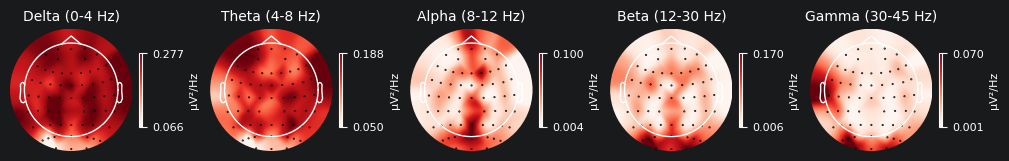

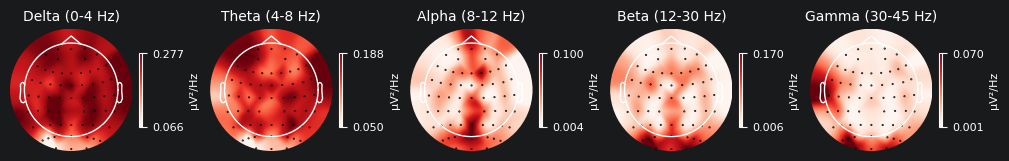

In [98]:
gait_ON.plot_psd_topomap(tmin=-0.25, tmax=0.25, normalize=True)


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows


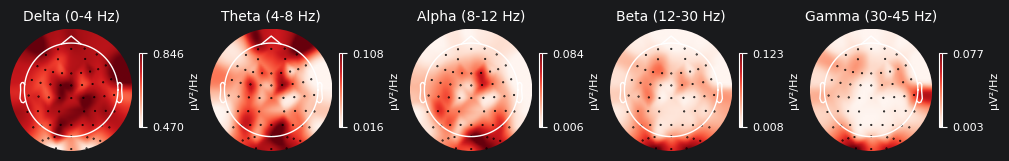

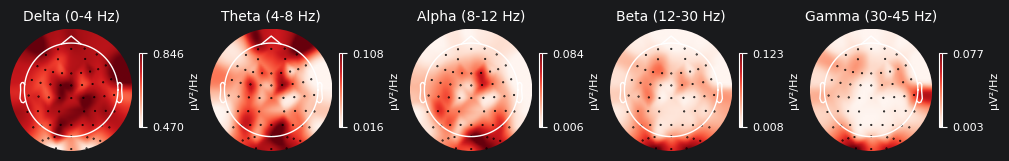

In [123]:
gait_OFF.plot_psd_topomap(tmin=-1.0, tmax=2,normalize=True)


Standing UP: ON + OFF Stim

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows


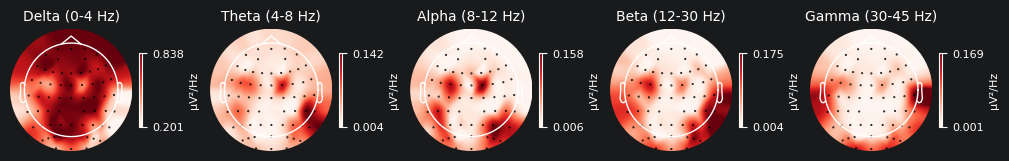

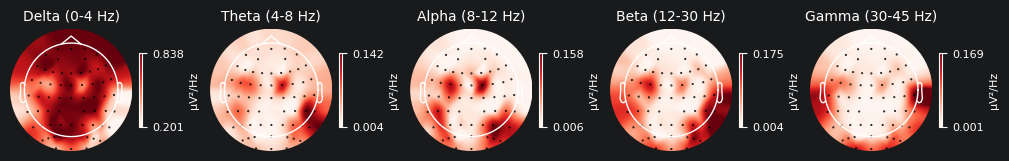

In [70]:
stand_ON.plot_psd_topomap(tmin=-1.5, tmax=-0.250, normalize=True)


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows


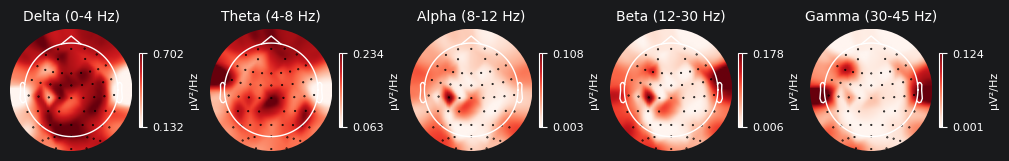

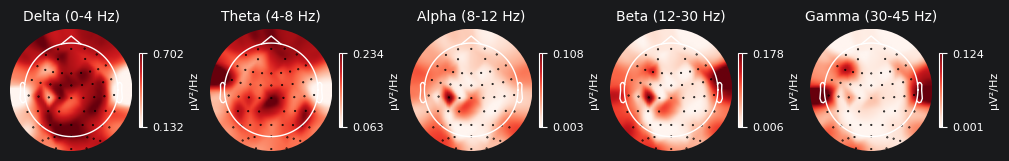

In [102]:
stand_OFF.plot_psd_topomap(tmin=-0.5, tmax=0.250, normalize=True)

TFR

In [ ]:
standup = mne.read_epochs("/home/hamzeh/Documents/MEAOW_project/pilot_data/preprocessed_files/Ash/task/Ash_standup-epo.fif")
gait = mne.read_epochs("/home/hamzeh/Documents/MEAOW_project/pilot_data/preprocessed_files/Ash/task/Ash_gait-epo.fif")

In [81]:
freqs = np.logspace(*np.log10([1, 40]), num=100)
n_cycle = freqs/2

baseline_mode = 'logratio'

In [ ]:
baseline = (-3, -2)
power_StON, itc = mne.time_frequency.tfr_multitaper(standup["StimON_StandUp"], freqs=freqs, n_cycles=n_cycle, n_jobs=-1)
power_StOFF, itc = mne.time_frequency.tfr_multitaper(standup["StimOFF_StandUp"], freqs=freqs, n_cycles=n_cycle, n_jobs=-1)

In [ ]:
power_StON.crop(-2, 0.25)
power_StOFF.crop(-2, 0.25)
power_StON.plot(baseline=baseline, mode = baseline_mode, picks='Cz')
power_StOFF.plot(baseline=baseline, mode = baseline_mode, picks='Cz')

In [ ]:
baseline = (-2, -1)

power_GON, itc = mne.time_frequency.tfr_multitaper(gait["StimON_Gait"], freqs=freqs, n_cycles=n_cycle, n_jobs=-1)


power_GOFF , itc = mne.time_frequency.tfr_multitaper(gait["StimOFF_Gait"], freqs=freqs, n_cycles=n_cycle, n_jobs=-1)

power_GON.crop(-2, 1)
power_GOFF.crop(-2, 1)

In [ ]:

# power_GON.crop(-2, 1)
# power_GOFF.crop(-2, 1)
roi_channels = ['C1', 'C3', 'CP1', 'CP3']
power_GON.plot(mode = baseline_mode, picks=roi_channels)
power_GOFF.plot(mode = baseline_mode, picks=roi_channels)

Applying baseline correction (mode: zscore)
X shape: (751,)
Y shape: (751,)


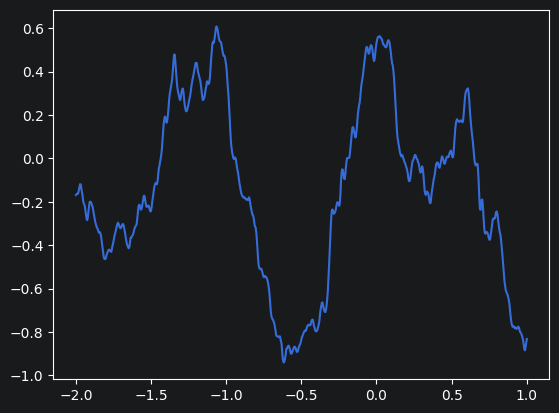

In [111]:
import matplotlib.pyplot as plt

# power_GON.plot(baseline=baseline, mode = baseline_mode, picks='Cz')
# power_GOFF.plot(baseline=baseline, mode = baseline_mode, picks='Cz')

beta_data_ON = power_GON.copy().apply_baseline(baseline=(-2, -1), mode="zscore").crop(fmin=13, fmax=33)
erd_sig1 = beta_data_ON.data.mean(axis=(0, 1))


# 2. Extract the times
times_array = beta_data_ON.times
print(f"X shape: {times_array.shape}")  # Will print (563,)
print(f"Y shape: {erd_sig.shape}")   # Will print (563,)
# 3. Now it will plot perfectly!
plt.plot(times_array, erd_sig)
plt.show()

Applying baseline correction (mode: zscore)
X shape: (751,)
Y shape: (751,)


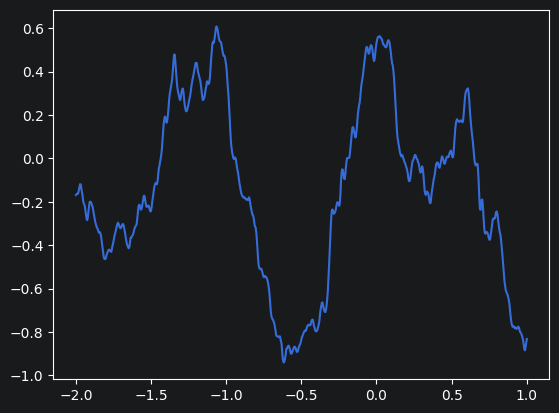

In [112]:
beta_data_OFF = power_GOFF.copy().apply_baseline(baseline=(-2, -1), mode="zscore").crop(fmin=13, fmax=33)
erd_sig2 = beta_data_OFF.data.mean(axis=(0, 1))


# 2. Extract the times
times_array = beta_data_OFF.times
print(f"X shape: {times_array.shape}")  # Will print (563,)
print(f"Y shape: {erd_sig.shape}")   # Will print (563,)
# 3. Now it will plot perfectly!
plt.plot(times_array, erd_sig)
plt.show()

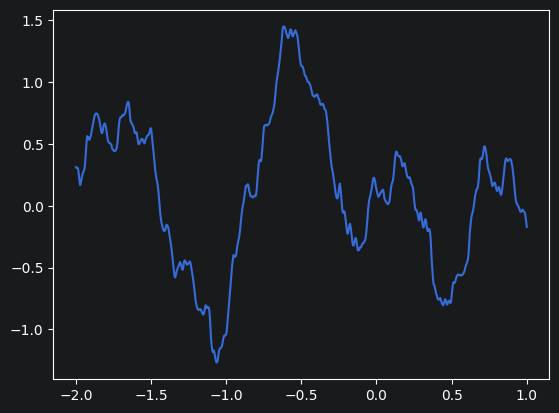

In [113]:
diff_Stim = erd_sig1 - erd_sig2

plt.plot(times_array, diff_Stim)
plt.show()

In [104]:
standup = mne.read_epochs("/home/hamzeh/Documents/MEAOW_project/pilot_data/preprocessed_files_backUp/preprocessed_files/zoh/task/zoh_standup-epo.fif")
gait = mne.read_epochs("/home/hamzeh/Documents/MEAOW_project/pilot_data/preprocessed_files_backUp/preprocessed_files/zoh/task/zoh_gait-epo.fif")

Reading /home/hamzeh/Documents/MEAOW_project/pilot_data/preprocessed_files_backUp/preprocessed_files/zoh/task/zoh_standup-epo.fif ...
    Found the data of interest:
        t =   -1500.00 ...     300.00 ms
        0 CTF compensation matrices available
Not setting metadata
247 matching events found
No baseline correction applied
0 projection items activated
Reading /home/hamzeh/Documents/MEAOW_project/pilot_data/preprocessed_files_backUp/preprocessed_files/zoh/task/zoh_gait-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
247 matching events found
No baseline correction applied
0 projection items activated


In [ ]:
power_StON, itc = mne.time_frequency.tfr_multitaper(standup["StimON_StandUp"], freqs=freqs, n_cycles=n_cycle, n_jobs=-1)
power_StOFF, itc = mne.time_frequency.tfr_multitaper(standup["StimOFF_StandUp"], freqs=freqs, n_cycles=n_cycle, n_jobs=-1)

power_GON, itc = mne.time_frequency.tfr_multitaper(gait["StimON_Gait"], freqs=freqs, n_cycles=n_cycle, n_jobs=-1)
power_GOFF, itc = mne.time_frequency.tfr_multitaper(gait["StimOFF_Gait"], freqs=freqs, n_cycles=n_cycle, n_jobs=-1)


In [ ]:
baseline = (-2, -1.5)
baseline_mode = 'logratio'
# power_StON.crop(-1.5, 0.2)
# power_StOFF.crop(-1.5, 0.2)
power_StON.plot(baseline=baseline, mode = baseline_mode, picks=['C1', 'C3', 'CP1', 'CP3'])
power_StOFF.plot(baseline=baseline, mode = baseline_mode, picks=['C1', 'C3', 'CP1', 'CP3'])

In [ ]:
baseline = (-2, -1.5)
power_GON.crop(-2, 1)
power_GOFF.crop(-2, 1)
power_GON.plot(baseline=baseline, mode = baseline_mode, picks=['C1', 'C3', 'CP1', 'CP3'])
power_GOFF.plot(baseline=baseline, mode = baseline_mode, picks=['C1', 'C3', 'CP1', 'CP3'])

In [121]:
tfr_roi = power_GOFF.pick(roi_channels)
adjacency, ch_names = mne.channels.find_ch_adjacency(power_GOFF.info, ch_type='eeg')
adjacency

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 4


<Compressed Sparse Row sparse array of dtype 'int64'
	with 14 stored elements and shape (4, 4)>

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Select your Motor ROI channels and target frequency band (e.g., Beta: 14-30 Hz)
roi_channels = ['C1', 'C3', 'CP1', 'CP3'] # Adjust to your left/right motor ROI
tfr_roi = power_StON.copy().pick(roi_channels).crop(fmin=14, fmax=30)

# 2. Extract Power(task) over time
# Average the data across Channels (axis 0) and Frequencies (axis 1)
# This gives you a 1D array of raw power over time
power_task = tfr_roi.data.mean(axis=(0, 1))

# 3. Calculate Power(baseline)
# Find the indices for your baseline window (e.g., -2.0 to -1.0 seconds)
base_time_mask = (tfr_roi.times >= -3.0) & (tfr_roi.times <= -2.0)
power_baseline = power_task[base_time_mask].mean()

# 4. Apply YOUR exact formula: ERD = [Power(task) - Power(baseline)] / Power(baseline)
# erd_signal = (power_task - power_baseline) / power_baseline
erd_signal = 10*np.log10(power_task/power_baseline)
# Optional: Multiply by 100 to make it a percentage
erd_signal_percent = erd_signal

# 5. Plot the 1D ERD/ERS Signal
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the main signal
ax.plot(tfr_roi.times, erd_signal_percent, color='blue', linewidth=2.5, label='Beta ERD/ERS')

# Add visual markers for context
ax.axhline(0, color='black', linestyle='-', linewidth=1) # Zero-line (No change)
ax.axvline(0, color='red', linestyle='--', label='Movement Trigger (t=0)')
ax.axvspan(-3.0, -2.0, color='gray', alpha=0.2, label='Baseline Window')

# Formatting
ax.set_title("Beta Band (14-30 Hz) ERD/ERS Signal", fontsize=14, fontweight='bold')
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("ERD / ERS (%)", fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'power_StON' is not defined